## 1. Imports

In [14]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from collections import defaultdict
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import roc_curve, roc_auc_score


from flow_tree_utils import plot_flow_tree, generate_traj_from_path, generate_flow_tree_from_trajs

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [2]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

In [3]:
# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
test_df["accuracy"] = test_df["accuracy"].astype(bool)

test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
test_df["traj_strs"] = test_df["trajs"].apply("".join)

## 3. Try to predict individual success from location on Flow Tree

The thought is to create a Flow Tree with 70% of the data, will you be able to predit if an indiidual gets it right or wrong depending on where they are on the Flow Tree **before they finish**

### Do indiv predictions one Flow Tree

In [18]:
def generate_likelihoods_for_person_for_path(G, train_df, test_row):
    test_traj = test_row["trajs"]

    likelihoods_by_level = []
    alleged_test_flow_tree_path = ["".join(test_traj[:i]) for i in range(len(test_traj))]
    special_visits = []
    for step in alleged_test_flow_tree_path:
        if step not in G.nodes(): 
            # Either completely diverged or completely unanimous
            continue

        # If it is node in flow tree you can count the trajectories with this 
        # prefix and calculate likelihood from this. Kinda hacky. Doable just 
        # from the tree, but this seems much easier.
        matching_trajs = train_df[train_df["traj_strs"].str.contains(step)]
        likelihood = len(matching_trajs[matching_trajs["accuracy"]]) / len(matching_trajs)
        likelihoods_by_level.append(likelihood)

        special_visits.append(step)
    return likelihoods_by_level, special_visits

Individual subject #110 got it wrong.
Their trajectory: AGHQRUTXT.Q
Likelihoods by level: [0.5185185185185185, 0.6, 0.71875, 0.36363636363636365, 0.5714285714285714, 0.6666666666666666]


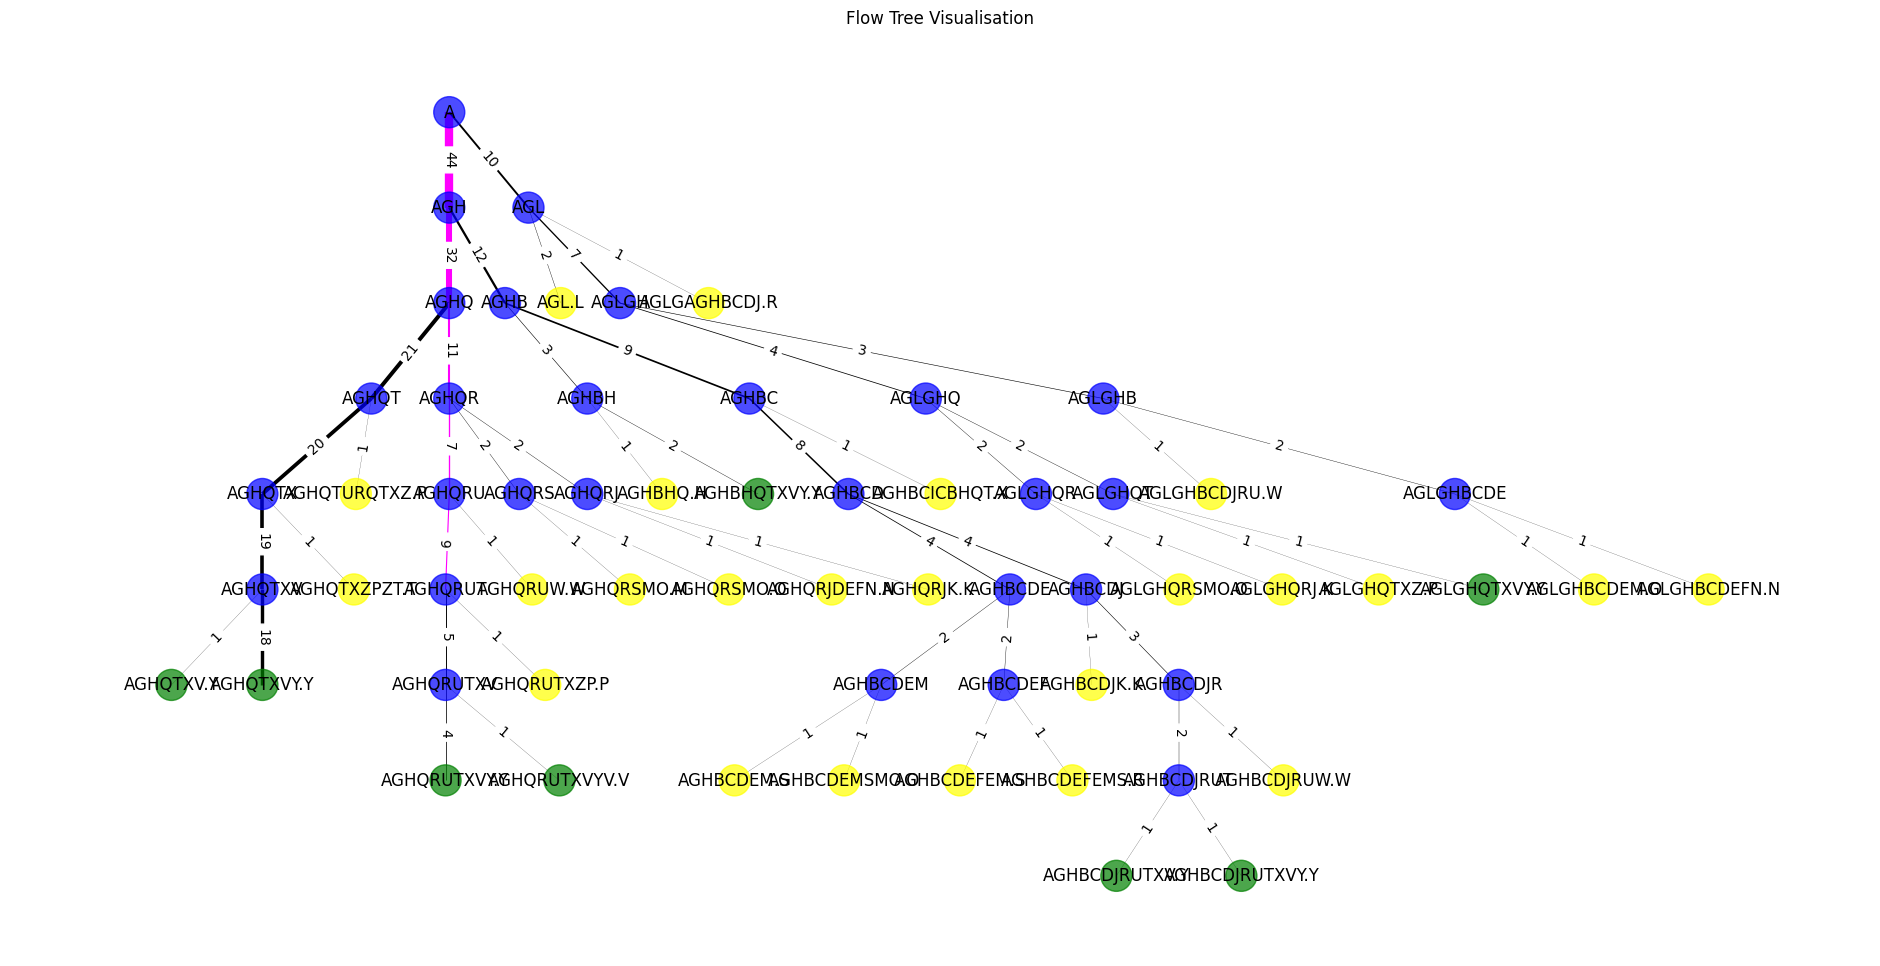

Individual subject #103 got it right.
Their trajectory: AGHQTXVY.Y
Likelihoods by level: [0.5185185185185185, 0.6, 0.71875, 0.9047619047619048, 0.95, 1.0]


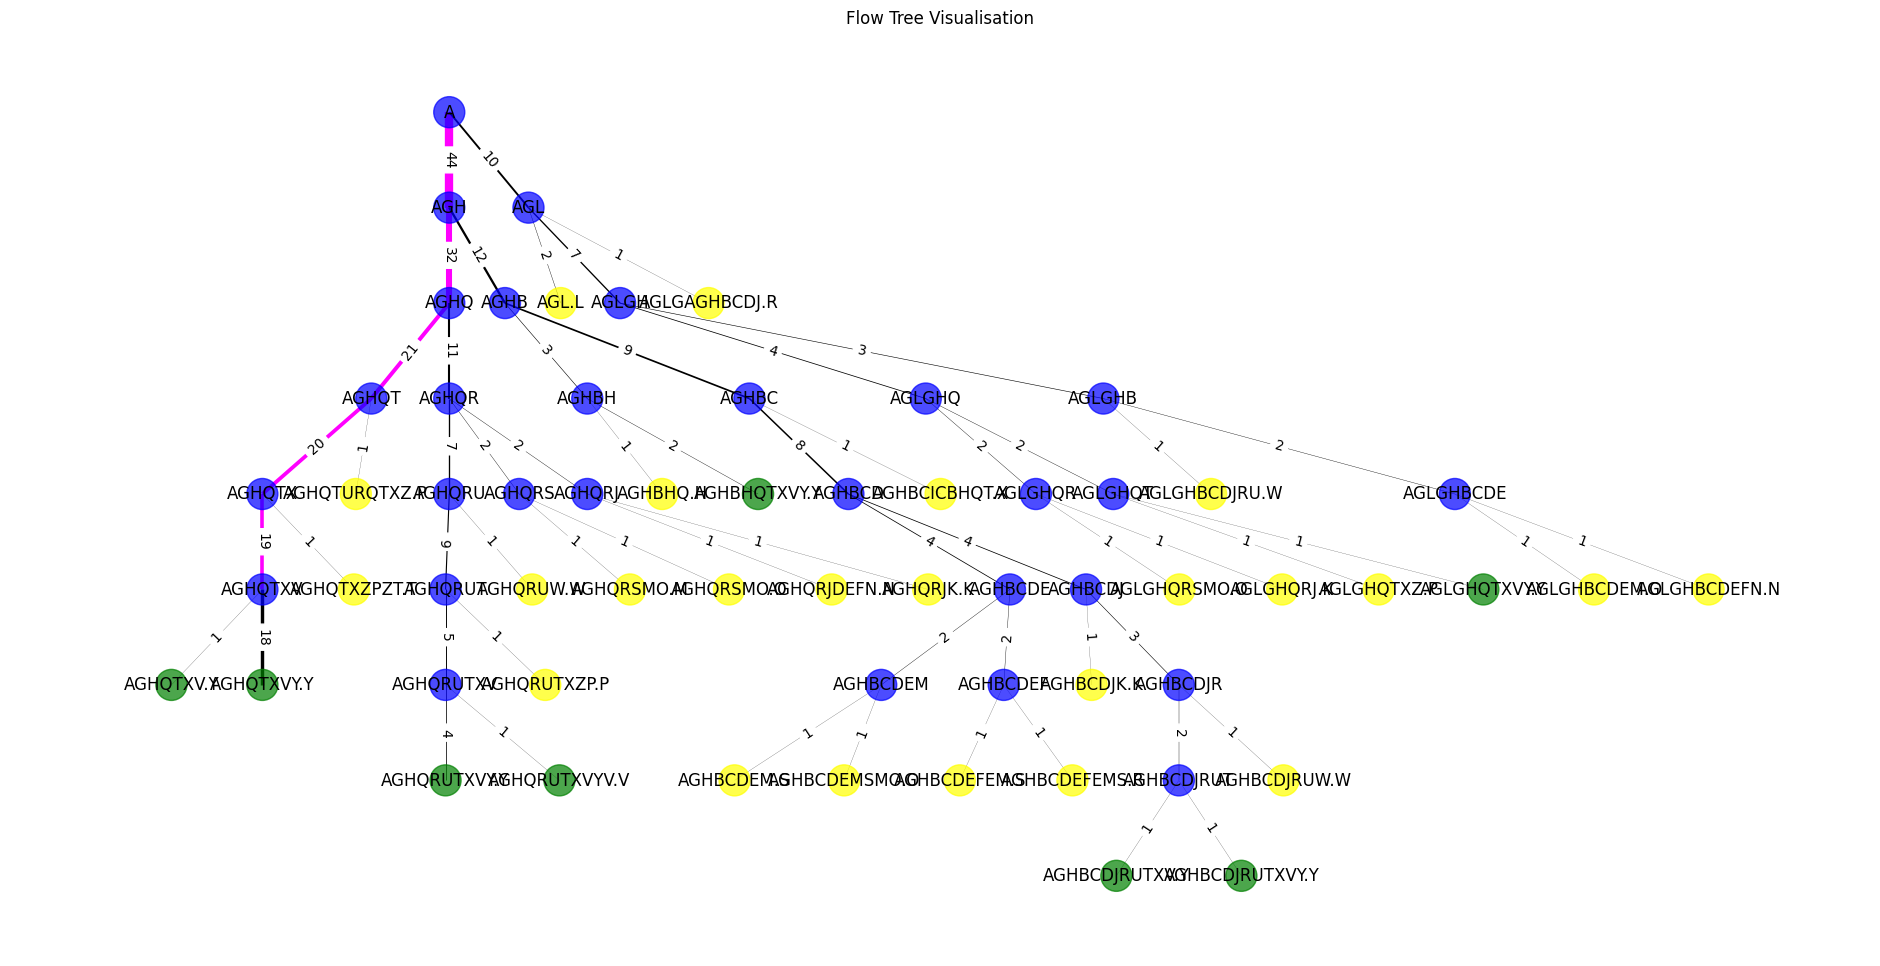

Individual subject #59 got it right.
Their trajectory: AGHQTXVY.Y
Likelihoods by level: [0.5185185185185185, 0.6, 0.71875, 0.9047619047619048, 0.95, 1.0]


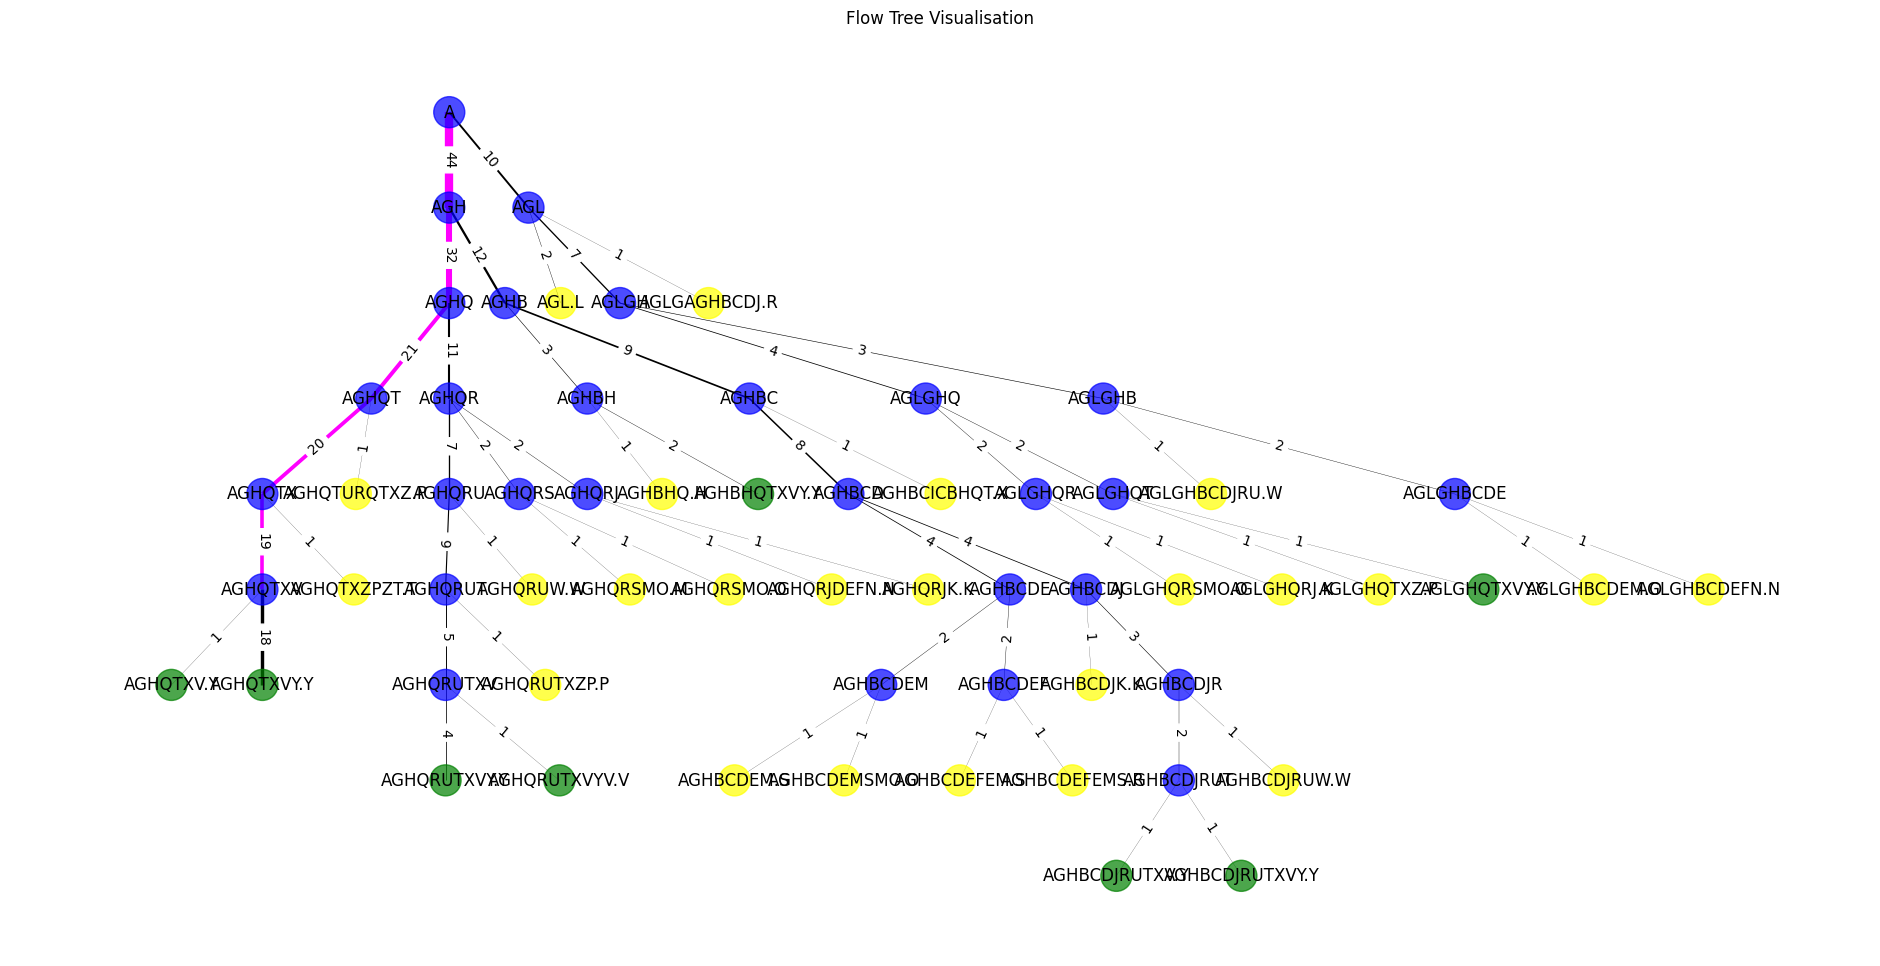

In [20]:
start_node, end_node = "A", "Y"

this_path_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]
train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=6)

count, how_many_to_plot = 0, 3

train_trajs = np.array(train_this_path_df["trajs"])
G = generate_flow_tree_from_trajs(train_trajs, END_NODE=end_node)
    
# Identify where one person's path is through the Flow Tree
for _, test_row in test_this_path_df.iterrows():
    test_subject_number = test_row["Subject"]
    
    likelihoods_by_level, special_visits = generate_likelihoods_for_person_for_path(G, train_this_path_df, test_row)
    
    print(f"Individual subject #{test_subject_number} got it {'right' if test_row['accuracy'] else 'wrong'}.")
    print("Their trajectory:", "".join(test_row["trajs"]))
    print("Likelihoods by level:", likelihoods_by_level)

    special_edges = [(special_visits[sv-1], special_visits[sv]) for sv in range(1, len(special_visits))]
    # plot_treeb_special_path(G, special_edges)#, with_nodes=True)
    
    plt.figure(figsize=(24,12))
    ax = plt.gca()

    plot_flow_tree(G, "Flow Tree Visualisation", ax, special_edges=special_edges)
    plt.title("Flow Tree Visualisation")

    plt.show()

    count += 1
    if count == how_many_to_plot:
        break


### ROC curve for one Flow Tree

In [25]:
def generate_likelihoods_by_person_for_path(test_df, start_node, end_node, add_random=True, k_fold=5):
    k_likelihoods_by_level_by_person = defaultdict(list)
    k_actual_accuracies_by_level_by_person = defaultdict(list)

    this_path_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]

    # Do each Flow Tree k_fold times
    for k in range(k_fold):
        likelihoods_by_level_by_person = defaultdict(list)
        actual_accuracies_by_level_by_person = defaultdict(list)

        train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=k)

        train_trajs = np.array(train_this_path_df["trajs"])
        G = generate_flow_tree_from_trajs(train_trajs, END_NODE=end_node)

        # Identify where one person's path is through the Flow Tree
        for _, test_row in test_this_path_df.iterrows():
            test_subject_number = test_row["Subject"]
            actual_acc = int(test_row["accuracy"])

            likelihoods_by_level, special_visits = generate_likelihoods_for_person_for_path(G, train_this_path_df, test_row)
            
            # Keep track of all of the predictions for all the levels
            for lvl, lik in enumerate(likelihoods_by_level):
                likelihoods_by_level_by_person[lvl].append(lik)
                actual_accuracies_by_level_by_person[lvl].append(actual_acc)

        for lvl in likelihoods_by_level_by_person:
            k_likelihoods_by_level_by_person[lvl].append(likelihoods_by_level_by_person[lvl])
            k_actual_accuracies_by_level_by_person[lvl].append(actual_accuracies_by_level_by_person[lvl])

    if add_random:
        k_likelihoods_by_level_by_person["rand"] = [[random.random() for _ in each_kfold] for each_kfold in k_actual_accuracies_by_level_by_person[0]]
        k_actual_accuracies_by_level_by_person["rand"] = k_actual_accuracies_by_level_by_person[0][:]

    return k_likelihoods_by_level_by_person, k_actual_accuracies_by_level_by_person

In [28]:
### Compute and plot ROC curve for ONE Flow Tree ###
start_node, end_node = "N", "A"
k_likelihoods_by_level_by_person, k_actual_accuracies_by_level_by_person = generate_likelihoods_by_person_for_path(test_df, start_node, end_node, add_random=True, k_fold=5)

fig = go.Figure()

roc_data = {}
cs = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', '#B6E880', '#FF97FF', '#FECB52']
ci = 0
for lvl in k_likelihoods_by_level_by_person:

    # Store ROC values for each level to compute mean and thresholds
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 101)

    for y_prob, y_test in zip(k_likelihoods_by_level_by_person[lvl], k_actual_accuracies_by_level_by_person[lvl]):
    
        # gonna be illegal to do ROC
        if len(y_test) == 0 or len(set(y_test)) == 1:
            continue

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        aucs.append(roc_auc)

        # Interpolate TPRs over the mean FPR
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tprs.append(tpr_interp)

    if len(tprs) == 0: continue

    # Calculate the mean and standard deviation of the TPRs
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    # Calculate the upper and lower bounds of the shaded area (mean ± 1 std dev)
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)   

    # print(mean_tpr)
    # print(mean_fpr)

    # Plot mean ROC curve
    fig.add_trace(go.Scatter(
        x=mean_fpr, y=mean_tpr,
        mode='lines',
        line=dict(color=cs[ci], width=2),
        name=f"level {lvl}"
    ))

    # Plot the shadow (error band)
    fig.add_trace(go.Scatter(
        x=np.concatenate([mean_fpr, mean_fpr[::-1]]),
        y=np.concatenate([tpr_upper, tpr_lower[::-1]]),
        fill='toself',
        opacity=0.1,
        fillcolor=cs[ci],
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='1 std dev'
    ))

    ci += 1

# Customize layout
fig.update_layout(
    title="Mean ROC Curves with 5-Fold Cross-Validation",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    showlegend=True,
    width=800,
    height=600
)
    
# Show plot
fig.show()

### Do this for all Flow Trees

In [35]:
K_FOLD = 10

count = 0
plot_xs = []
plot_ys = []


k_likelihoods_by_level_by_tree_by_person = defaultdict(list)
k_actual_accuracies_by_level_by_tree_by_person = defaultdict(list)
path_diffs_by_level = defaultdict(list)

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    k_likelihoods_by_level_by_person, k_actual_accuracies_by_level_by_person = generate_likelihoods_by_person_for_path(group, start_node, end_node, add_random=True, k_fold=K_FOLD)
   
    for lvl in k_likelihoods_by_level_by_person:
        k_likelihoods_by_level_by_tree_by_person[lvl].append(k_likelihoods_by_level_by_person[lvl])
        k_actual_accuracies_by_level_by_tree_by_person[lvl].append(k_actual_accuracies_by_level_by_person[lvl])
        path_diffs_by_level[lvl].append(group["path_mean_acc"].iloc[0])

### Plot ROC curves per level, averaged across all paths/Flow Trees

In [36]:
fig = go.Figure()

aucs_by_level = defaultdict(list)
colors = defaultdict(list)

cs = ['#0d0887', '#46039f', '#7201a8', '#9c179e', '#bd3786', '#d8576b', '#ed7953', '#fb9f3a', '#fdca26', '#f0f921']
ci = 0
for lvl in k_likelihoods_by_level_by_tree_by_person:

    # Store ROC values for each level to compute mean and thresholds
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 101)

    for tp_idx in range(len(k_likelihoods_by_level_by_tree_by_person[lvl])):
        this_level_this_tree_aucs = []
        for y_prob, y_test in zip(k_likelihoods_by_level_by_tree_by_person[lvl][tp_idx], 
                                  k_actual_accuracies_by_level_by_tree_by_person[lvl][tp_idx]):
        
            # gonna be illegal to do ROC
            if len(y_test) == 0 or len(set(y_test)) == 1:
                continue
    
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = roc_auc_score(y_test, y_prob)
            # print(y_test)
            # print(y_prob)
            aucs.append(roc_auc)
            this_level_this_tree_aucs.append(roc_auc)
            # print(roc_auc)
    
            # Interpolate TPRs over the mean FPR
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tprs.append(tpr_interp)

        if len(this_level_this_tree_aucs) > 0:
            aucs_by_level[lvl].append(np.mean(this_level_this_tree_aucs))
            colors[lvl].append(path_diffs_by_level[lvl][tp_idx])
    
    if len(tprs) == 0: continue

    # Calculate the mean and standard deviation of the TPRs
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    # Calculate the upper and lower bounds of the shaded area (mean ± 1 std dev)
    tpr_upper = np.minimum(mean_tpr + .5*std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - .5*std_tpr, 0)   

    # print(mean_tpr)
    # print(mean_fpr)

    # Plot mean ROC curve
    fig.add_trace(go.Scatter(
        x=mean_fpr, y=mean_tpr,
        mode='lines',
        line=dict(color=cs[ci], width=2),
        name=f"level {lvl} (auc={np.mean(aucs):0.2f})"
    ))

    # Plot the shadow (error band)
    fig.add_trace(go.Scatter(
        x=np.concatenate([mean_fpr, mean_fpr[::-1]]),
        y=np.concatenate([tpr_upper, tpr_lower[::-1]]),
        fill='toself',
        opacity=0.05,
        fillcolor=cs[ci],
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='1 std dev'
    ))

    ci += 1

# Customize layout
fig.update_layout(
    title=f"Mean ROC Curves with {K_FOLD}-Fold Cross-Validation",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    showlegend=True,
    width=800,
    height=600
)
    
# Show plot
fig.show()

In [37]:
print([len(aucs_by_level[l]) for l in aucs_by_level])

[72, 72, 72, 68, 57, 30, 72, 9, 2]


In [39]:
import plotly.graph_objects as go
import numpy as np

# Example structure for aucs_by_level and colors
# aucs_by_level = {1: [0.6, 0.7], 2: [0.8, 0.65], 3: [0.5, 0.55]}
# colors = {1: [0.55, 0.7], 2: [0.9, 0.6], 3: [0.4, 0.48]}

fig = go.Figure()

# Flatten the data for scatter plot
xs = []
ys = []
cs = []

# Calculate means and stds for each level
mean_xs = []
mean_ys = []
std_ys = []

for lvl in aucs_by_level:
    # Collect data for scatter
    xs.extend([lvl] * len(aucs_by_level[lvl]))  # Repeat level value
    ys.extend(aucs_by_level[lvl])               # Y values (AUCs)
    cs.extend(colors[lvl])                      # Color values (continuous scale)
    
    # Calculate mean and std for current level
    mean_xs.append(lvl)
    mean_ys.append(np.mean(aucs_by_level[lvl]))
    std_ys.append(np.std(aucs_by_level[lvl]))

# Scatter plot using Plotly with continuous color scale
fig.add_trace(go.Scatter(
    x=xs, y=ys,
    mode='markers',
    marker=dict(
        size=10,
        color=cs,              # Color based on the values in 'cs'
        colorscale='thermal',   # Choose a continuous color scale (e.g., Viridis)
        colorbar=dict(
            title="Path difficulty\n(mean subj accuracy)"  # Title for the colorbar
        ),
        showscale=True,         # Show the color scale legend
        opacity=0.3
    ),
    name='AUC Scatter'
))

# Add mean points with error bars for standard deviation
fig.add_trace(go.Scatter(
    x=mean_xs, y=mean_ys,
    mode='markers',
    opacity=0.7,
    error_y=dict(
        type='data',
        array=std_ys,  # Standard deviation
        visible=True
    ),
    marker=dict(
        size=12,
        color='black',
        symbol='x'  # Use 'x' symbol for the mean points
    ),
    # line=dict(dash='dash'),
    name='Mean AUC ± 1 std'
))

# Customize the layout
fig.update_layout(
    title="AUC of ROC curve by Flow-Tree prediction depth (with Mean and Std)",
    xaxis_title="Prediction Depth",
    yaxis_title="AUC",
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 1.1]),  # Adjust y-axis to fit AUC values
    showlegend=False,
    width=800,
    height=600
)

# Show the plot
fig.show()
